# Part 1 – Data Acquisition, Cleaning and Exploratory Data Analysis

In this notebook, I perform the complete data cleaning and exploratory data analysis process on the selected dataset. The goal is to understand the data, identify quality issues, handle missing values, detect outliers, and prepare a clean dataset for machine learning in the next part of the project.


## Importing the Required Libraries

First, I import all the libraries needed for data manipulation, visualization, and statistical analysis.


In [8]:
import pandas as pd
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [24]:
import os

os.makedirs("plots", exist_ok=True)

## Loading the Dataset

Here I load the dataset into a pandas DataFrame and take an initial look at the data by checking the first few rows, data types, and overall dimensions.


In [11]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

df.head()

Saving AmesHousing.csv to AmesHousing.csv


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Missing Value Analysis

In this section, I check each column for missing values, calculate the percentage of missing data, identify columns with a high percentage of null values, and fill eligible numerical columns using the median.



In [12]:
null_count = df.isnull().sum()

null_percent = (null_count / len(df))*100

null_table = pd.DataFrame({
    "Missing Count": null_count,
    "Missing %": null_percent
})

print(null_table)

print("\nColumns >20% missing\n")

print(null_table[null_table["Missing %"]>20])

                Missing Count  Missing %
Order                       0   0.000000
PID                         0   0.000000
MS SubClass                 0   0.000000
MS Zoning                   0   0.000000
Lot Frontage              490  16.723549
...                       ...        ...
Mo Sold                     0   0.000000
Yr Sold                     0   0.000000
Sale Type                   0   0.000000
Sale Condition              0   0.000000
SalePrice                   0   0.000000

[82 rows x 2 columns]

Columns >20% missing

              Missing Count  Missing %
Alley                  2732  93.242321
Mas Vnr Type           1775  60.580205
Fireplace Qu           1422  48.532423
Pool QC                2917  99.556314
Fence                  2358  80.477816
Misc Feature           2824  96.382253


In [13]:
for col in df.columns:

    if df[col].isnull().mean()*100 <20:

        if df[col].dtype!="object":

            df[col]=df[col].fillna(df[col].median())

## Duplicate Records

Before proceeding further, I check whether the dataset contains duplicate rows. If any duplicates are found, they are removed and the impact is recorded.



In [14]:
duplicates=df.duplicated().sum()

print("Duplicates:",duplicates)

before=df.shape[0]

df=df.drop_duplicates()

after=df.shape[0]

print("Rows removed:",before-after)

Duplicates: 0
Rows removed: 0


In [16]:
print(df.columns)

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

## Data Type Correction

Some columns may not have the correct data type after loading the dataset. Here I convert those columns into more appropriate data types and compare the memory usage before and after the conversion.


In [17]:
before_memory = df.memory_usage(deep=True).sum()

# Convert numeric-looking code to category
df["MS SubClass"] = df["MS SubClass"].astype("category")

# Convert repetitive string column to category
df["Neighborhood"] = df["Neighborhood"].astype("category")

after_memory = df.memory_usage(deep=True).sum()

print(f"Memory Before: {before_memory:,} bytes")
print(f"Memory After : {after_memory:,} bytes")
print(f"Memory Saved : {before_memory-after_memory:,} bytes")

Memory Before: 7,251,298 bytes
Memory After : 7,074,419 bytes
Memory Saved : 176,879 bytes


## Descriptive Statistics

This section provides a statistical summary of all numerical features, including measures such as mean, standard deviation, minimum, maximum, and quartiles.

In [20]:
# Descriptive statistics for numeric columns
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.describe())


            Order           PID  Lot Frontage       Lot Area  Overall Qual  \
count  2930.00000  2.930000e+03   2930.000000    2930.000000   2930.000000   
mean   1465.50000  7.144645e+08     69.019795   10147.921843      6.094881   
std     845.96247  1.887308e+08     21.326422    7880.017759      1.411026   
min       1.00000  5.263011e+08     21.000000    1300.000000      1.000000   
25%     733.25000  5.284770e+08     60.000000    7440.250000      5.000000   
50%    1465.50000  5.354536e+08     68.000000    9436.500000      6.000000   
75%    2197.75000  9.071811e+08     78.000000   11555.250000      7.000000   
max    2930.00000  1.007100e+09    313.000000  215245.000000     10.000000   

       Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  \
count   2930.000000  2930.000000     2930.000000   2930.000000   2930.000000   
mean       5.563140  1971.356314     1984.266553    101.096928    442.604778   
std        1.111537    30.245361       20.860286    178.6

## Skewness Analysis

Here I calculate the skewness of every numerical feature to understand the shape of each distribution and identify the most highly skewed columns.


In [21]:
skewness = numeric_df.skew()

print("\nSkewness of Numeric Columns:")
print(skewness)

# Find the column with the highest absolute skewness
highest = skewness.abs().idxmax()

print(f"\nMost Skewed Column: {highest}")
print(f"Skewness Value: {skewness[highest]:.3f}")


Skewness of Numeric Columns:
Order               0.000000
PID                 0.055886
Lot Frontage        1.670204
Lot Area           12.820898
Overall Qual        0.190634
Overall Cond        0.574429
Year Built         -0.604462
Year Remod/Add     -0.451863
Mas Vnr Area        2.619305
BsmtFin SF 1        1.416567
BsmtFin SF 2        4.140794
Bsmt Unf SF         0.923403
Total Bsmt SF       1.156532
1st Flr SF          1.469429
2nd Flr SF          0.866457
Low Qual Fin SF    12.118162
Gr Liv Area         1.274110
Bsmt Full Bath      0.617728
Bsmt Half Bath      3.942389
Full Bath           0.171952
Half Bath           0.697713
Bedroom AbvGr       0.305694
Kitchen AbvGr       4.313825
TotRms AbvGrd       0.753543
Fireplaces          0.739215
Garage Yr Blt      -0.401196
Garage Cars        -0.220168
Garage Area         0.242001
Wood Deck SF        1.842678
Open Porch SF       2.535386
Enclosed Porch      4.014446
3Ssn Porch         11.403795
Screen Porch        3.957467
Pool Area    

## Outlier Detection using the IQR Method

Outliers are detected using the Interquartile Range (IQR) method. The purpose is only to identify them at this stage without removing any values.

In [22]:
columns = ["SalePrice", "Gr Liv Area"]

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

SalePrice: 137 outliers
Gr Liv Area: 75 outliers


## Line Plot

A line plot is created to visualize how one numerical variable changes across the dataset.

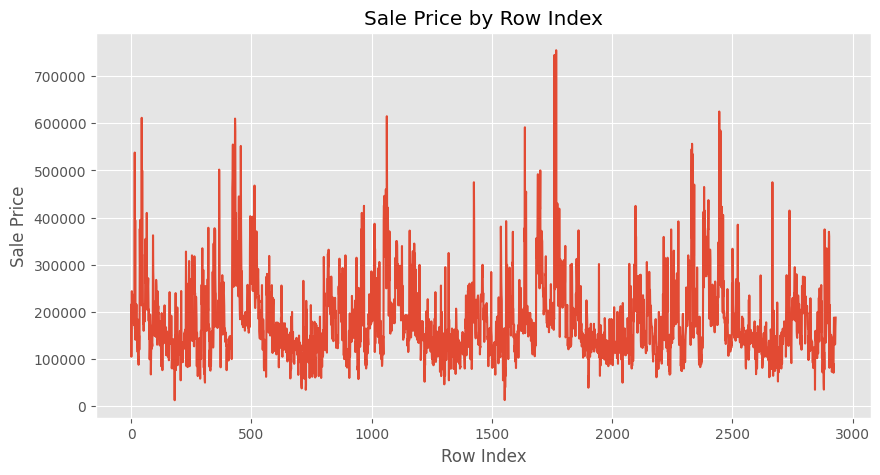

In [25]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df["SalePrice"])

plt.title("Sale Price by Row Index")
plt.xlabel("Row Index")
plt.ylabel("Sale Price")

plt.grid(True)

plt.savefig("plots/line_plot.png")

plt.show()

## Bar Chart

This visualization compares the average value of a numerical feature across different categories.


/tmp/ipykernel_417/848887486.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Neighborhood")["SalePrice"].mean().sort_values().plot.bar()


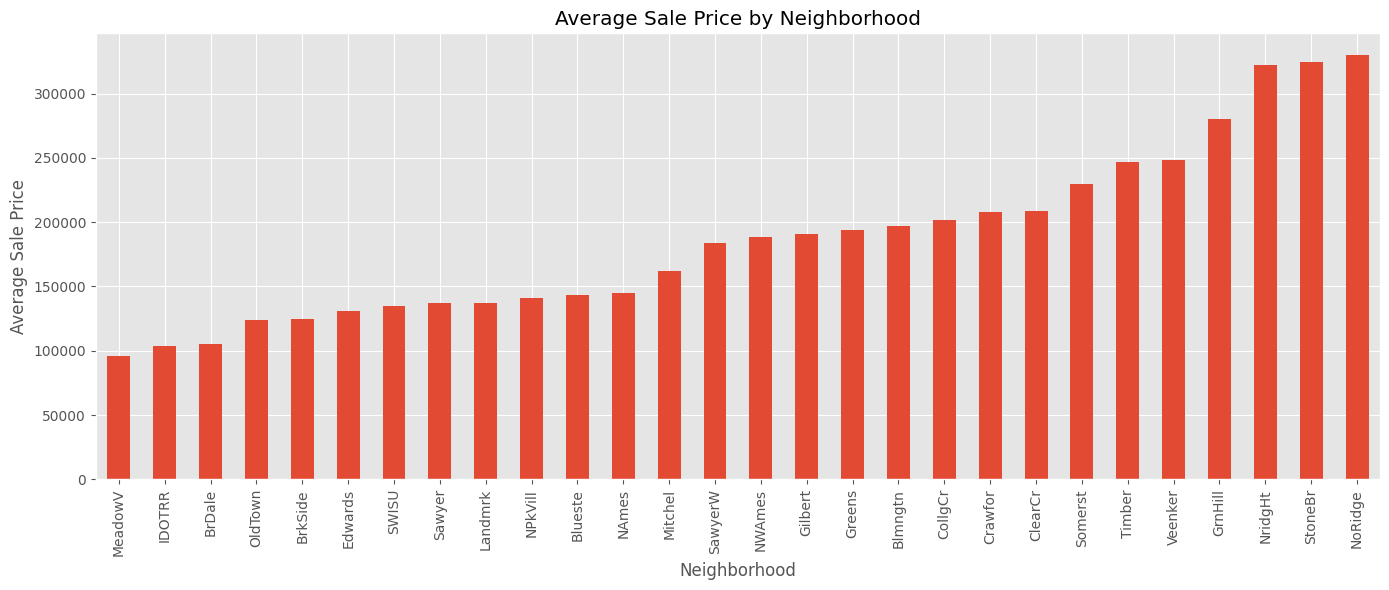

In [26]:
plt.figure(figsize=(14,6))

df.groupby("Neighborhood")["SalePrice"].mean().sort_values().plot.bar()

plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price")

plt.tight_layout()

plt.savefig("plots/bar_chart.png")

plt.show()

## Histogram

A histogram is used to examine the distribution of the most skewed numerical feature identified earlier.

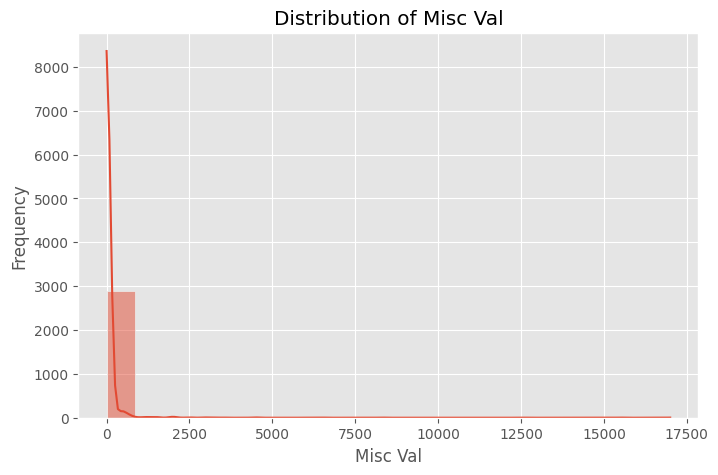

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df[highest], bins=20, kde=True)

plt.title(f"Distribution of {highest}")
plt.xlabel(highest)
plt.ylabel("Frequency")

plt.savefig("plots/histogram.png")

plt.show()

## Scatter Plot

A scatter plot helps visualize the relationship between two numerical variables and determine whether they appear to be correlated.

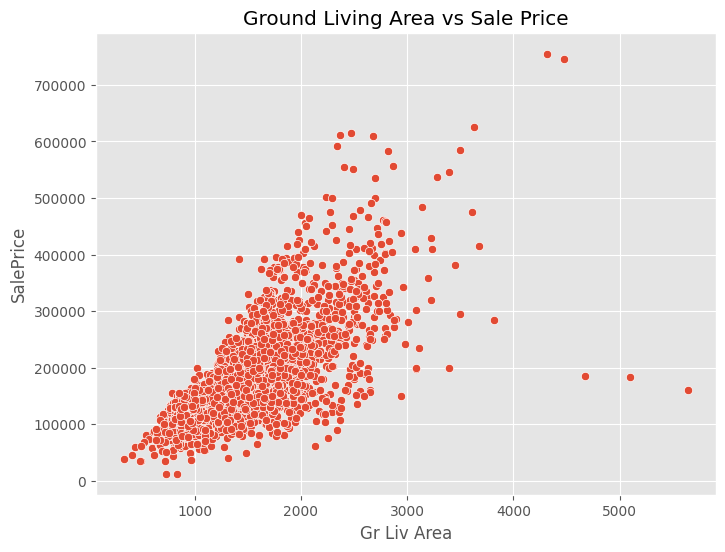

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Gr Liv Area",
    y="SalePrice"
)

plt.title("Ground Living Area vs Sale Price")

plt.savefig("plots/scatter_plot.png")

plt.show()

## Box Plot

A box plot is created to compare the distribution of a numerical feature across different categories and to identify outliers.

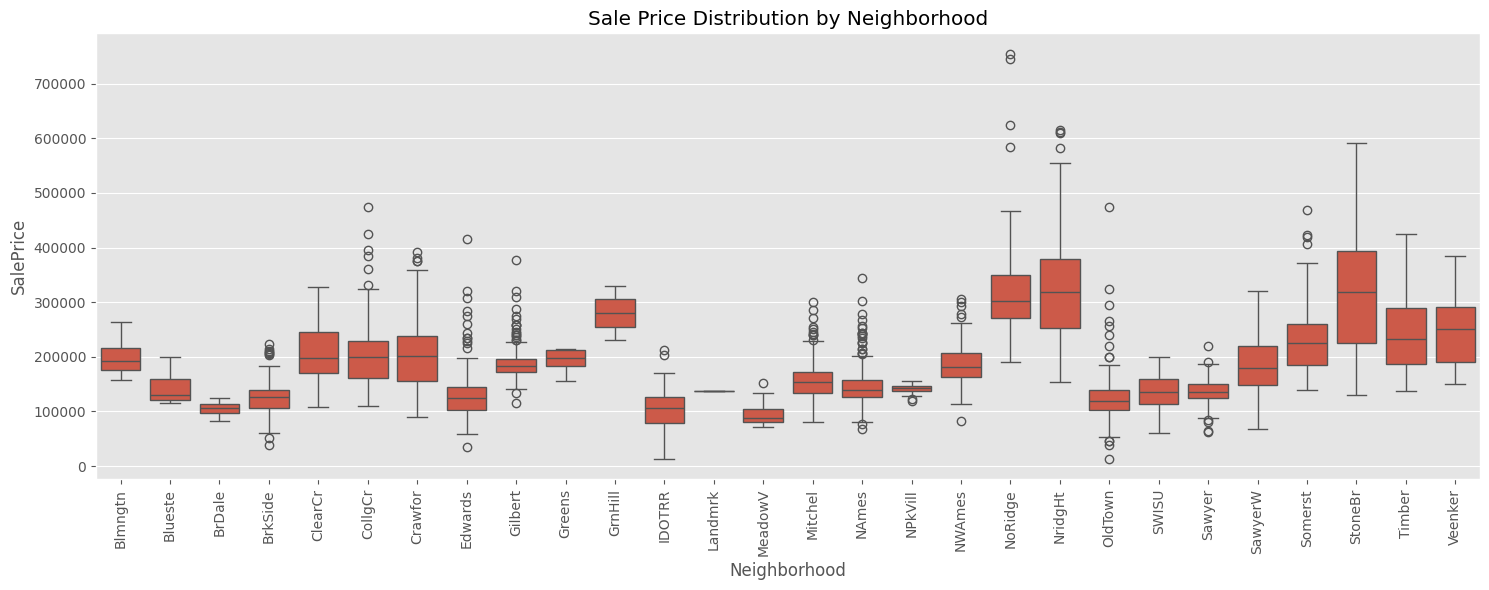

In [30]:
plt.figure(figsize=(15,6))

sns.boxplot(
    data=df,
    x="Neighborhood",
    y="SalePrice"
)

plt.xticks(rotation=90)

plt.title("Sale Price Distribution by Neighborhood")

plt.tight_layout()

plt.savefig("plots/box_plot.png")

plt.show()

## Correlation Analysis

In this section, I compute the Pearson correlation matrix and visualize it using a heat map to understand the relationships between numerical variables.

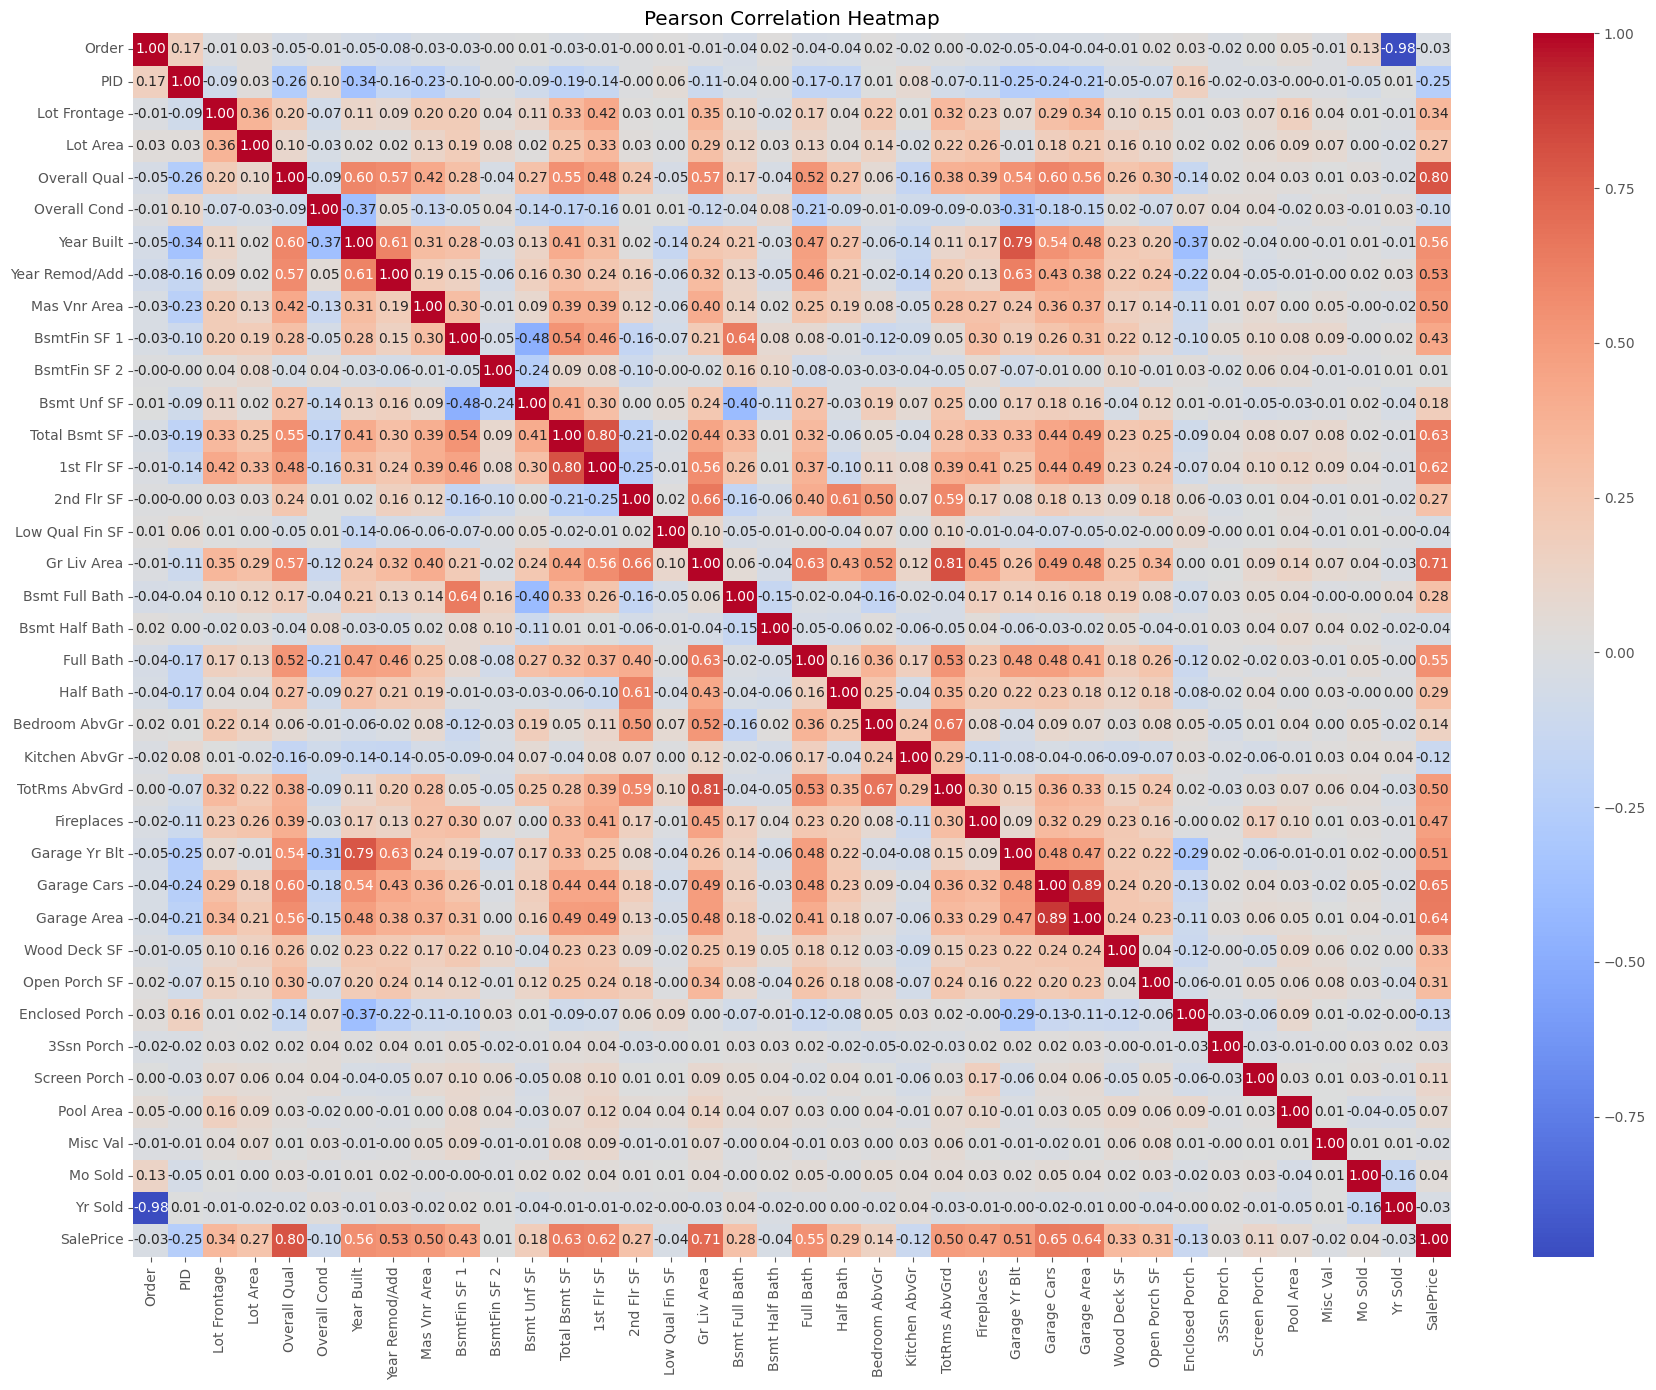

Order        Yr Sold          0.975993
Yr Sold      Order            0.975993
Garage Cars  Garage Area      0.889665
Garage Area  Garage Cars      0.889665
Gr Liv Area  TotRms AbvGrd    0.807772
dtype: float64


In [31]:
numeric_df = df.select_dtypes(include=["number"])

corr = numeric_df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Pearson Correlation Heatmap")

plt.tight_layout()

plt.savefig("plots/correlation_heatmap.png")

plt.show()

# Strongest correlated pair
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]

print(corr_pairs.sort_values(ascending=False).head())

## Comparing Mean and Median for Imputation

Here I compare the mean and median values of the two most skewed numerical columns before deciding which measure is more suitable for imputing missing values.

In [32]:
top2 = skewness.abs().sort_values(ascending=False).head(2).index

for col in top2:

    print(f"\nColumn: {col}")

    print("Mean   :", df[col].mean())

    print("Median :", df[col].median())

    df[col] = df[col].fillna(df[col].median())

print("\nRemaining Missing Values")

print(df[top2].isnull().sum())


Column: Misc Val
Mean   : 50.63515358361775
Median : 0.0

Column: Pool Area
Mean   : 2.243344709897611
Median : 0.0

Remaining Missing Values
Misc Val     0
Pool Area    0
dtype: int64


## Spearman Rank Correlation

Along with Pearson correlation, I calculate the Spearman correlation matrix to identify monotonic relationships and compare both methods.


In [33]:
pearson = numeric_df.corr()

spearman = numeric_df.corr(method="spearman")

difference = (spearman - pearson).abs()

print("Pearson Correlation Matrix")
print(pearson)

print("\nSpearman Correlation Matrix")
print(spearman)

pairs = (
    difference.where(~np.eye(difference.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print("\nTop 3 Largest Differences")
print(pairs.head(3))

Pearson Correlation Matrix
                    Order       PID  Lot Frontage  Lot Area  Overall Qual  \
Order            1.000000  0.173593     -0.006102  0.031354     -0.048500   
PID              0.173593  1.000000     -0.087894  0.034868     -0.263147   
Lot Frontage    -0.006102 -0.087894      1.000000  0.362758      0.198917   
Lot Area         0.031354  0.034868      0.362758  1.000000      0.097188   
Overall Qual    -0.048500 -0.263147      0.198917  0.097188      1.000000   
Overall Cond    -0.011054  0.104451     -0.067140 -0.034759     -0.094812   
Year Built      -0.052319 -0.343388      0.114341  0.023258      0.597027   
Year Remod/Add  -0.075566 -0.157111      0.086139  0.021682      0.569609   
Mas Vnr Area    -0.031045 -0.225672      0.201685  0.125950      0.423089   
BsmtFin SF 1    -0.032313 -0.098412      0.198161  0.191574      0.284091   
BsmtFin SF 2    -0.002758 -0.001245      0.039157  0.083198     -0.041122   
Bsmt Unf SF      0.005791 -0.087763      0.109586


## Grouped Aggregation

I perform grouped statistical analysis by calculating the mean, standard deviation, and count of a numerical feature for each category of a selected categorical variable.

In [34]:
group_stats = df.groupby("Neighborhood")["SalePrice"].agg(
    ["mean", "std", "count"]
)

print(group_stats)

highest_mean = group_stats["mean"].idxmax()
highest_std = group_stats["std"].idxmax()

ratio = group_stats["mean"].max() / group_stats["mean"].min()

print("\nHighest Mean Group :", highest_mean)
print("Highest Std Group  :", highest_std)
print(f"Mean Ratio         : {ratio:.2f}")

                       mean            std  count
Neighborhood                                     
Blmngtn       196661.678571   29317.511457     28
Blueste       143590.000000   30158.523763     10
BrDale        105608.333333   12144.773839     30
BrkSide       124756.250000   35740.935575    108
ClearCr       208662.090909   51280.213463     44
CollgCr       201803.434457   54187.843749    267
Crawfor       207550.834951   65230.183286    103
Edwards       130843.381443   48030.405046    194
Gilbert       190646.575758   33050.029652    165
Greens        193531.250000   21998.554133      8
GrnHill       280000.000000   70710.678119      2
IDOTRR        103752.903226   36493.911013     93
Landmrk       137000.000000            NaN      1
MeadowV        95756.486486   20130.564823     37
Mitchel       162226.631579   41356.861245    114
NAmes         145097.349887   31882.707229    443
NPkVill       140710.869565    9340.283679     23
NWAmes        188406.908397   37687.782531    131


/tmp/ipykernel_417/3171546888.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby("Neighborhood")["SalePrice"].agg(


## Saving the Cleaned Dataset

Finally, the cleaned dataset is saved as **cleaned_data.csv** so that it can be used in Parts 2 and 3 of the project.

In [35]:
df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv has been saved successfully.")

cleaned_data.csv has been saved successfully.
